# Playground

In [265]:
import geopandas as gpd
import osmnx
import pandas as pd
import numpy as np
from libpysal.cg.shapely_ext import distance
from pandas.core.arrays import categorical
from shapely import geometry, set_precision
import shapely
from shapely.geometry.linestring import LineString
from shapely.ops import unary_union, split
import networkx as nx
import osmnx as ox
import momepy
import matplotlib.pyplot as plt
import contextily as cx
import copy

from sympy.physics.units import length

In [266]:
def plot_maps(*maps):
    fig, ax = plt.subplots()
    for map, color in maps:
        map.plot(ax=ax, color=color)
    cx.add_basemap(ax=ax, crs=maps[0][0].crs, source=cx.providers.CartoDB.Positron)
    plt.show()

## Validate CRS function

In [267]:
def validate_crs(gdf):
    if gdf.crs.is_geographic:
        gdf = gdf.to_crs(epsg=4326)
        return gdf.to_crs(gdf.estimate_utm_crs())
    return gdf

## Centroid function

In [268]:
def get_centroids(gdf):
    gdf = validate_crs(gdf)
    gdf['shape_centroid'] = gdf.geometry.centroid
    return gdf

In [269]:
gdf_shape = gpd.read_file('test_shapes.gpkg')
get_centroids(gdf_shape)

,id,feat,geometry,shape_centroid
0,1,first,"MULTIPOLYGON (((322109.431 4730357.405, 322255...",POINT (321816.211 4730103.326)
1,2,second,"MULTIPOLYGON (((322535.551 4730198.913, 322504...",POINT (322622.382 4730293.955)
2,3,third,"MULTIPOLYGON (((322285.486 4729706.411, 322224...",POINT (322362.492 4729893.569)


## Segment function

In [270]:
def preprocess_route(gdf_polylines):
    gdf_polylines = validate_crs(gdf_polylines)

    segmented_lines = unary_union(gdf_polylines.geometry)
    segmented_lines = shapely.get_parts(segmented_lines)
    segments = []
    for line in segmented_lines:
        coords = list(line.coords)
        for i in range(len(coords) - 1):
            segments.append(shapely.geometry.LineString([coords[i], coords[i + 1]]))

    return gpd.GeoDataFrame(geometry=segments, crs=gdf_polylines.crs)

In [271]:
gdf_lines = gpd.read_file('test_lines2.gpkg')
preprocess_route(gdf_lines).geometry

0     LINESTRING (322140.932 4730394.071, 322234.37 ...
1     LINESTRING (322234.37 4730493.546, 322314.936 ...
2     LINESTRING (322314.936 4730579.318, 322544.927...
3     LINESTRING (322544.927 4730381.365, 322462.129...
4     LINESTRING (322462.129 4730299.918, 322298.947...
5     LINESTRING (322298.947 4730139.397, 321424.348...
6     LINESTRING (321424.348 4729770.724, 321395.375...
7     LINESTRING (321395.375 4729832.373, 321449.876...
8     LINESTRING (321449.876 4730126.306, 321489.203...
9     LINESTRING (321489.203 4730338.405, 321507.324...
10    LINESTRING (321446.182 4730344.025, 321489.203...
11    LINESTRING (321489.203 4730338.405, 321624.421...
12    LINESTRING (321624.421 4730320.743, 321781.21 ...
13    LINESTRING (321781.21 4730300.262, 321795.727 ...
14    LINESTRING (321795.727 4730407.63, 321884.513 ...
15    LINESTRING (321884.513 4730386.608, 321899.872...
16    LINESTRING (321899.872 4730435.399, 322002.69 ...
17    LINESTRING (322002.69 4730503.02, 322099.4

## Snap targets to route function



In [272]:
def extend_route_to_centroids(gdf_polylines, gdf):
    gdf_polylines = validate_crs(gdf_polylines.to_crs(gdf.crs))
    gdf = validate_crs(gdf)

    gdf_snapped = gpd.sjoin_nearest(get_centroids(gdf), gdf_polylines, how='left')[['shape_centroid', 'index_right']].drop_duplicates(subset='shape_centroid')
    gdf_snapped = gdf_snapped.merge(gdf_polylines[['geometry']], left_on='index_right', right_index=True)
    gdf_snapped['start_line'] = gdf_snapped['geometry'].interpolate(gdf_snapped['geometry'].project(gdf_snapped['shape_centroid']))
    new_rows = []
    for row in gdf_snapped.iloc:
        new_rows.append({'geometry': LineString([row['start_line'], row['shape_centroid']])})
    new_gdf = gpd.GeoDataFrame(new_rows, crs=gdf_polylines.crs)
    return pd.concat([gdf_polylines, new_gdf], ignore_index=True)


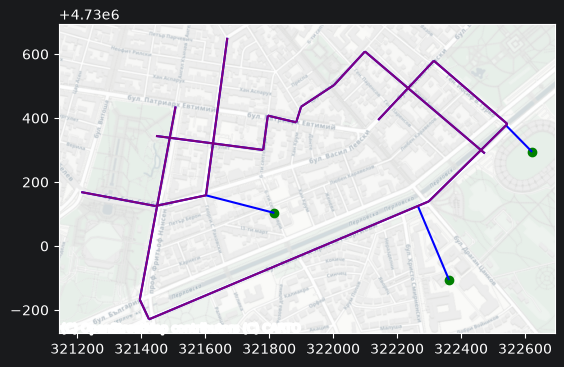

In [273]:
snapped_targets = extend_route_to_centroids(preprocess_route(gdf_lines), get_centroids(gdf_shape))
# snapped_targets
plot_maps((snapped_targets, 'blue'), (get_centroids(gdf_shape)['shape_centroid'], 'green'), (preprocess_route(gdf_lines), 'purple'))

In [274]:
# Start Here

## Segment line with snapped points function

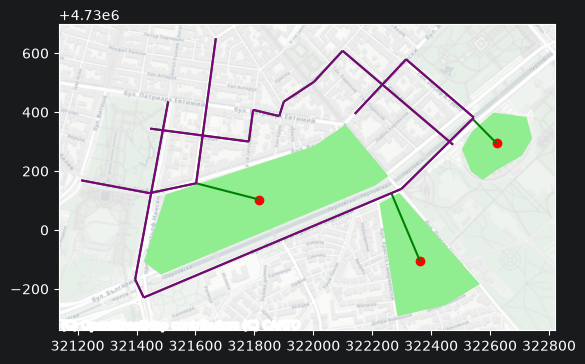

In [275]:
lines = gpd.read_file('test_lines2.gpkg')
shape = gpd.read_file('test_shapes.gpkg')

route = preprocess_route(lines)
route = extend_route_to_centroids(route, shape)
route = preprocess_route(route)

plot_maps((route, 'green'), (shape, 'lightgreen'), (preprocess_route(lines), 'purple'), (shape.centroid, 'red'))

## Create isochrones function

In [361]:
def create_isochrones(network, starting_point, distance):
    if isinstance(network, gpd.GeoDataFrame):
        network = momepy.gdf_to_nx(network, approach='primal', length='length', directed=True)
        nearest_node = min(network.nodes, key=lambda node: starting_point.distance(shapely.geometry.Point(node)))
    else:
        nearest_node = ox.nearest_nodes(G=network, X=[starting_point.x], Y=[starting_point.y])[0]

    isochrone = nx.ego_graph(network, nearest_node, radius=distance, distance='length', undirected=True)
    isochrone = ox.graph_to_gdfs(isochrone, nodes=False, edges=True)
    isochrone = validate_crs(isochrone)
    return isochrone

### testing polyline graph

EPSG:7801


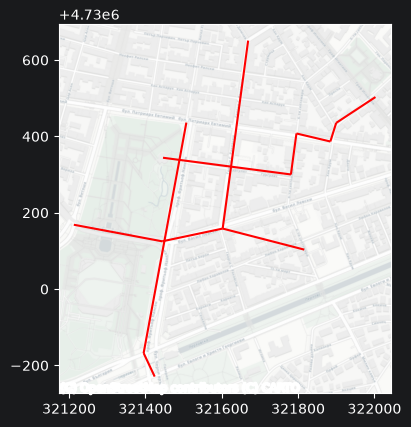

In [296]:
i = create_isochrones(route, shape.centroid.iloc[0], 1000)
plot_maps((i, 'red'))

### testing OSM graph

In [278]:
route_osm = ox.graph_from_polygon(shape.to_crs(epsg=4326).iloc[0].geometry, network_type='walk')

In [279]:
j = create_isochrones(route_osm, shape.centroid.iloc[0], 500)
# plot_maps((j, 'red'))
j = j.reset_index()

epsg:4326


## Accessibility function

In [386]:
target = gpd.read_file('test_target.gpkg')
# gpd.sjoin_nearest(target, j.to_crs(target.crs), how='left')
route = extend_route_to_centroids(route, target)
route = preprocess_route(route)

In [333]:
i = create_isochrones(route, shape.centroid.iloc[0], 1000)

EPSG:7801


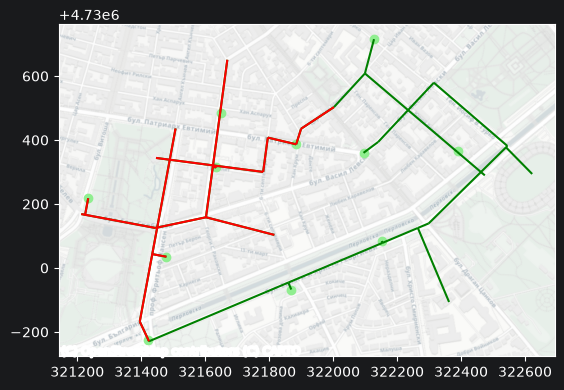

In [337]:
plot_maps( (route, 'green'), (target.centroid, 'lightgreen'), (i, 'red'),)

In [374]:
i_p = i.buffer(10).union_all()
c = gpd.sjoin(gpd.GeoDataFrame(geometry=[i_p], crs=target.crs), target, how='inner',  predicate='intersects')
c

,geometry,index_right,type,shape_centroid
0,"POLYGON ((321433.771 4729774.069, 321434.054 4...",10,c,POINT (321420.477 4729773.548)
0,"POLYGON ((321433.771 4729774.069, 321434.054 4...",0,a,POINT (321478.82 4730035.12)
0,"POLYGON ((321433.771 4729774.069, 321434.054 4...",9,b,POINT (321234.147 4730217.986)
0,"POLYGON ((321433.771 4729774.069, 321434.054 4...",3,a,POINT (321634.327 4730314.596)
0,"POLYGON ((321433.771 4729774.069, 321434.054 4...",8,b,POINT (321649.244 4730485.281)
0,"POLYGON ((321433.771 4729774.069, 321434.054 4...",2,a,POINT (321884.991 4730388.19)


In [390]:
def isochrone_target_intersection(isochrone, *targets):
    isochrone_buffered = isochrone.buffer(10).union_all()
    count = 0
    for target in targets:
        joined = gpd.sjoin(gpd.GeoDataFrame(geometry=[isochrone_buffered], crs=target.crs), target, how='inner',  predicate='intersects')
        if len(joined) > 0:
            count += 1

    return count

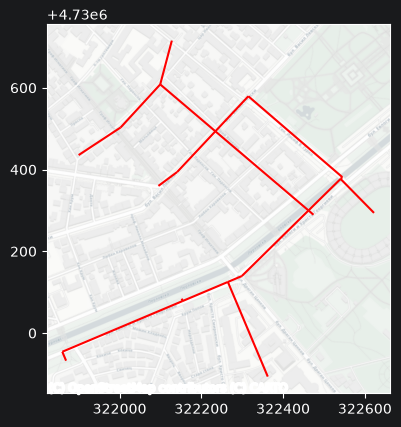

In [388]:
k = create_isochrones(route, shape.centroid.iloc[1], 1000)
plot_maps((k, 'red'))

In [379]:
isochrone_target_intersection(i, target[target['type'] == 'a'], target[target['type'] == 'b'], target[target['type'] == 'c'])

3

In [389]:
isochrone_target_intersection(k, target[target['type'] == 'a'], target[target['type'] == 'b'], target[target['type'] == 'c'])

2

## Accessibility analysis function

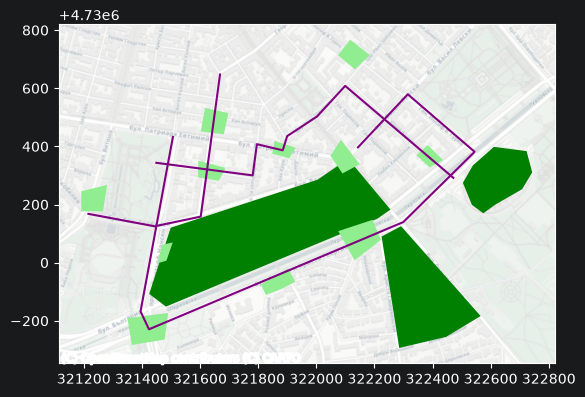

In [393]:
start = gpd.read_file('test_shapes.gpkg')
target = gpd.read_file('test_target.gpkg')
route = gpd.read_file('test_lines2.gpkg')

plot_maps((start, 'green'), (target, 'lightgreen'), (route, 'purple'))

In [412]:
def accessibility_analysis(start, route, *targets):
    route = preprocess_route(route)
    route = extend_route_to_centroids(route, start)
    route = preprocess_route(route)
    route = extend_route_to_centroids(route, target)
    start = get_centroids(start)
    start['accessibility'] = start.apply(lambda row: isochrone_target_intersection(create_isochrones(route, row['shape_centroid'], 1000), *targets), axis=1)
    return start

In [413]:
targets = [target[target['type'] == 'a'], target[target['type'] == 'b'], target[target['type'] == 'c']]
start = accessibility_analysis(start, route, *targets)

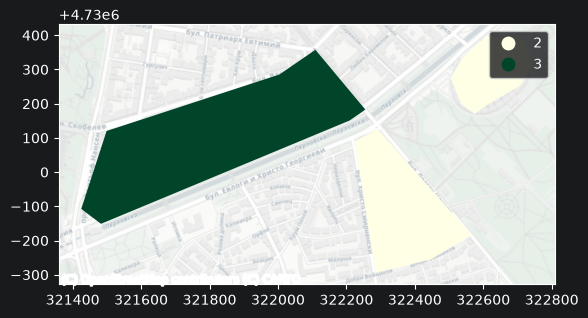

In [414]:
fig, ax = plt.subplots()
start.plot(ax=ax, column='accessibility', cmap='YlGn', legend=True, categorical=True)
cx.add_basemap(ax=ax, crs=start.crs, source=cx.providers.CartoDB.Positron)

In [420]:
route_osm_graph = ox.graph_from_polygon(shapely.box(*shape.to_crs(epsg=4326).total_bounds), network_type='walk')
route_osm = ox.graph_to_gdfs(route_osm_graph, nodes=False, edges=True)

In [421]:
start_osm = accessibility_analysis(start, route_osm, *targets)

In [422]:
start_osm

,id,feat,geometry,shape_centroid,accessibility
0,1,first,"MULTIPOLYGON (((322109.431 4730357.405, 322255...",POINT (321816.211 4730103.326),3
1,2,second,"MULTIPOLYGON (((322535.551 4730198.913, 322504...",POINT (322622.382 4730293.955),2
2,3,third,"MULTIPOLYGON (((322285.486 4729706.411, 322224...",POINT (322362.492 4729893.569),2
